# M2 Ejercicio: Variables, Datos y Estructuras

Guillermo Hernández Ruiz de Esparza

### Area de especializacion
Analisis de deportes

### Escenario
El curling es un deporte olimpico de invierno que se juega en una pista de hielo. Un juego se divide en 10 rondas, en cada ronda, cada equipo lanza 8 piedras. El objetivo es acercar las piedras lo mas posible a un objetivo llamado "casa" (un circulo dibujado en el hielo). Al final de cada ronda se otorgan puntos al equipo que tenga la piedra mas cercana a la casa; en caso que ningun equipo tenga una piedra dentro de la casa, no se otorgan puntos. El equipo con mas puntos al final de las 10 rondas gana el juego, un equipo puede decidir retirarse antes de que termine el juego, en ese caso el equipo contrario gana automaticamente. Si al final de las 10 rondas ambos equipos tienen la misma cantidad de puntos, se extiende a rondas adicionales.

Para este ejercicio plantee 2 objetivos:
1. Definir el ganador de cada juego
2. Mostrar la diferencia de puntos por ronda entre los equipos que ganan y los que pierden

### Ejercicio
Los datos de este ejercicio son de los juegos olimpicos de invierno de 2026:
* los 2 juegos de semifinales
* juego por el tercer lugar
* final 

### Propuesta
* Almacenar la informacion de los juegos en diccionarios y los resultados de cada ronda en listas
* Crear un nuevo diccionario para saber quien gano y perdio cada juego y elmarcador final
* Manejar las excepciones por tipo de dato (uno de los juegos termino en la ronda 9 por rendicion)
* Generar un diccionario con la diferencia de puntos al final de cada ronda

In [7]:
resultados = {
    "Semifinal 1": {
        "equipo1": "Gran Bretaña",
        "equipo2": "Suiza",
        "Gran Bretaña": [0, 0, 2, 0, 1, 1, 0, 2, 0, 2],
        "Suiza": [0, 2, 0, 2, 0, 0, 1, 0, 0, 0]
    },
    "Semifinal 2": {
        "equipo1": "Noruega",
        "equipo2": "Canadá",
        "Noruega": [0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0],
        "Canadá": [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1]
    },
    "Tercer lugar": {
        "equipo1": "Noruega",
        "equipo2": "Suiza",
        "Noruega": [0, 0, 0, 0, 1, 0, 0, 0, 0, "X"],
        "Suiza": [0, 3, 1, 0, 0, 0, 0, 2, 3, "X"]
    },
    "Final": {
        "equipo1": "Gran Bretaña",
        "equipo2": "Canadá",
        "Gran Bretaña": [0, 2, 0, 1, 0, 2, 0, 1, 0, 0],
        "Canadá": [1, 0, 2, 0, 1, 0, 1, 0, 3, 1]
    }
}

### Definir el ganador de cada juego

En la funcion sumar_puntos se maneja la excepcion por tipo de dato. En el codigo principal se utiliza un for para iterar sobre los juegos y se usan condiciones if/else para imprimir el mensaje indicando al ganador y el marcador final, y guardar los datos en el diccionario resultados.

In [8]:
def sumar_puntos(puntos):
    try:
        return sum(puntos)
    except TypeError:
        return sum(p for p in puntos if isinstance(p, int))

In [9]:
resultados_finales = {}
for juego, equipos in resultados.items():
    puntos_equipo1 = sumar_puntos(equipos[equipos["equipo1"]])
    puntos_equipo2 = sumar_puntos(equipos[equipos["equipo2"]])

    print(f"{juego}:")
    if puntos_equipo1 > puntos_equipo2:
        print("{} le gano a {}, {} puntos a {}"
              .format(equipos["equipo1"], equipos["equipo2"], puntos_equipo1, puntos_equipo2))
        resultados_finales[juego] = {
            "equipo1": equipos["equipo1"],
            equipos["equipo1"]: puntos_equipo1,
            "equipo2": equipos["equipo2"],
            equipos["equipo2"]: puntos_equipo2
        }
    else:
        print("{} le gano a {}, {} puntos a {}"
              .format(equipos["equipo2"], equipos["equipo1"], puntos_equipo2, puntos_equipo1))
        resultados_finales[juego] = {
            "equipo1": equipos["equipo1"],
            equipos["equipo1"]: puntos_equipo1,
            "equipo2": equipos["equipo2"],
            equipos["equipo2"]: puntos_equipo2
        }
    print("-"*20)

Semifinal 1:
Gran Bretaña le gano a Suiza, 8 puntos a 5
--------------------
Semifinal 2:
Canadá le gano a Noruega, 5 puntos a 4
--------------------
Tercer lugar:
Suiza le gano a Noruega, 9 puntos a 1
--------------------
Final:
Canadá le gano a Gran Bretaña, 9 puntos a 6
--------------------


### Mostrar la diferencia de puntos por ronda

El manejo de excepciones ahora lo hice dentro del for. Se usa un ciclo for para iterar sobre los juegos y un ciclo anidado para iterar sobre las rondas de cada juego. Al final use condiciones if/else para imprimir los mensajes de cada equipo (mayor desventaja/nunca en desventaja y mayor ventaja/nunca en ventaja), y guardar los datos en el diccionario diferencia_puntos. Aqui use variables para ir almacenando el puntaje acumulado de cada equipo.

In [10]:
diferencias = {}
for juego, equipos in resultados.items():
    diferencia_equipo1 = []
    diferencia_equipo2 = []
    acumulado_equipo1 = 0
    acumulado_equipo2 = 0

    for p1, p2 in zip(equipos[equipos["equipo1"]], equipos[equipos["equipo2"]]):
        try:
            acumulado_equipo1 += p1
            acumulado_equipo2 += p2
            diferencia_equipo1.append(acumulado_equipo1 - acumulado_equipo2)
            diferencia_equipo2.append(acumulado_equipo2 - acumulado_equipo1)
        except TypeError:
            pass
    print(f"{juego}:")
    print(f"Ganador: {equipos['equipo1'] if diferencia_equipo1[-1] > 0 else equipos['equipo2']}")
    print(f"Diferencia acumulada por ronda para {equipos['equipo1']}: {diferencia_equipo1}")
    print(f"Diferencia acumulada por ronda para {equipos['equipo2']}: {diferencia_equipo2}")
    print()
    if min(diferencia_equipo1) == 0:
        print(f"{equipos['equipo1']} nunca estuvo en desventaja durante el juego.")
    else:
        print(f"La mayor desventaja de {equipos['equipo1']} fue de {min(diferencia_equipo1)} puntos.")
    if max(diferencia_equipo1) == 0:
        print(f"{equipos['equipo1']} nunca estuvo en ventaja durante el juego.")
    else:
        print(f"La mayor ventaja de {equipos['equipo1']} fue de {max(diferencia_equipo1)} puntos.")
    print()
    if min(diferencia_equipo2) == 0:
        print(f"{equipos['equipo2']} nunca estuvo en desventaja durante el juego.")
    else:
        print(f"La mayor desventaja de {equipos['equipo2']} fue de {min(diferencia_equipo2)} puntos.")
    if max(diferencia_equipo2) == 0:
        print(f"{equipos['equipo2']} nunca estuvo en ventaja durante el juego.")
    else:
        print(f"La mayor ventaja de {equipos['equipo2']} fue de {max(diferencia_equipo2)} puntos.")
    print("-"*20)

    diferencias[juego] = {
        "equipo1": equipos["equipo1"],
        equipos["equipo1"]: diferencia_equipo1,
        "equipo2": equipos["equipo2"],
        equipos["equipo2"]: diferencia_equipo2
    }

Semifinal 1:
Ganador: Gran Bretaña
Diferencia acumulada por ronda para Gran Bretaña: [0, -2, 0, -2, -1, 0, -1, 1, 1, 3]
Diferencia acumulada por ronda para Suiza: [0, 2, 0, 2, 1, 0, 1, -1, -1, -3]

La mayor desventaja de Gran Bretaña fue de -2 puntos.
La mayor ventaja de Gran Bretaña fue de 3 puntos.

La mayor desventaja de Suiza fue de -3 puntos.
La mayor ventaja de Suiza fue de 2 puntos.
--------------------
Semifinal 2:
Ganador: Canadá
Diferencia acumulada por ronda para Noruega: [0, -1, -2, -1, -1, -2, -2, -1, -2, 0, -1]
Diferencia acumulada por ronda para Canadá: [0, 1, 2, 1, 1, 2, 2, 1, 2, 0, 1]

La mayor desventaja de Noruega fue de -2 puntos.
Noruega nunca estuvo en ventaja durante el juego.

Canadá nunca estuvo en desventaja durante el juego.
La mayor ventaja de Canadá fue de 2 puntos.
--------------------
Tercer lugar:
Ganador: Suiza
Diferencia acumulada por ronda para Noruega: [0, -3, -4, -4, -3, -3, -3, -5, -8]
Diferencia acumulada por ronda para Suiza: [0, 3, 4, 4, 3, 3, 3

### Extra: Graficar la diferencia de puntos de los equipos que ganan

Aqui hice primero un ciclo for para obtener la lista de diferencia solo de los equipos que ganaron, el segundo for fue para graficarlos usando matplotlib. En el eje x se muestra el numero de ronda y en el eje y la diferencia de puntos.

In [11]:
import matplotlib.pyplot as plt

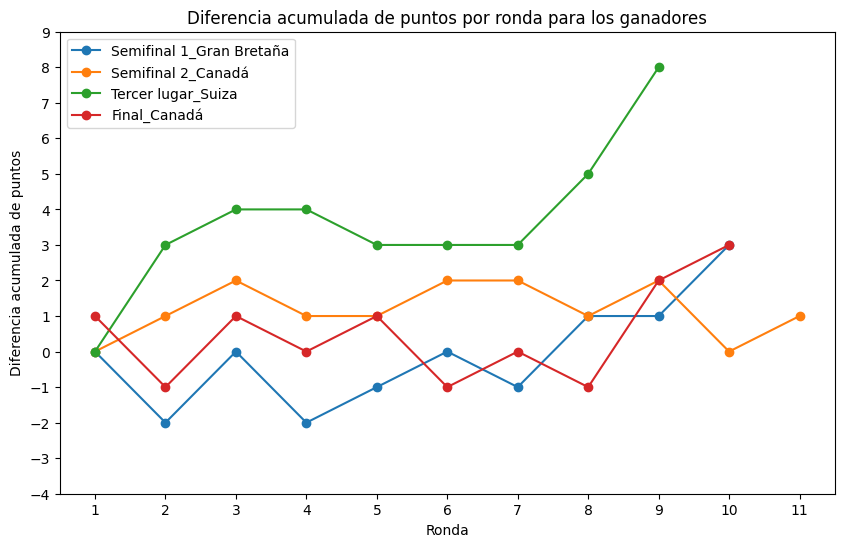

In [12]:
diferencias_ganadores = {}
for juego, equipos in diferencias.items():
    ganador = equipos["equipo1"] if equipos[equipos["equipo1"]][-1] > 0 else equipos["equipo2"]
    diferencias_ganadores[f"{juego}_{ganador}"] = equipos[ganador]
fig = plt.figure(figsize=(10, 6))
for juego_ganador, diferencia in diferencias_ganadores.items():
    x = list(range(1, len(diferencia) + 1))
    plt.plot(x, diferencia, label=juego_ganador, marker="o")
plt.title("Diferencia acumulada de puntos por ronda para los ganadores")
plt.xlabel("Ronda")
plt.ylabel("Diferencia acumulada de puntos")
plt.xticks(range(1, 12))
plt.yticks(range(-4, 10, 1))
plt.legend()

### Conclusiones
* El rango mas comun de diferencia de puntos por ronda es de -2 a 2, eso significa juegos muy cerrados
* 3 de los 4 juegos se definieron entre la 8 y la 10 ronda
* Existe otro factor que no se ve en esta grafica que cual equipo tiene el hammer (ultima piedra de la ronda)